In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Importing Libraries

In [13]:
import os
import cv2
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

Extract ZIP File

In [17]:
import zipfile

zip_path = "/content/drive/MyDrive/Colab Notebooks/PRAICP-1002-TrafSignDetc.zip"
extract_path = "/content/extracted_images"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(" Extraction completed")

 Extraction completed


Loading the Dataset

In [18]:
base_path = "/content/traffic_data/"   # after unzip

train_df = pd.read_csv(base_path + "Train.csv")
test_df = pd.read_csv(base_path + "Test.csv")
meta_df = pd.read_csv(base_path + "Meta.csv")

print(train_df.head())

   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  


Image Preprocessing

In [19]:
IMG_SIZE = 32

def preprocess(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img

Load Training Data

In [20]:
X = []
y = []

for i, row in train_df.iterrows():
    img_path = os.path.join("/content/extracted_images", row['Path'])
    label = row['ClassId']

    img = preprocess(img_path)

    X.append(img)
    y.append(label)

X = np.array(X)
y = np.array(y)   #  keep as integers

Convert to NumPy

In [21]:
import numpy as np

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (39209, 32, 32, 3)
y shape: (39209,)


Train-Test Split

In [22]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Build CNN Model

In [23]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(len(meta_df), activation='softmax'))  # number of classes

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,979 (1.22 MB)

 Trainable params: 319,979 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

Compile

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train CNN

In [25]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val)
)

Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.5139 - loss: 1.7124 - val_accuracy: 0.8820 - val_loss: 0.5494
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8193 - loss: 0.5804 - val_accuracy: 0.9508 - val_loss: 0.2094
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8857 - loss: 0.3605 - val_accuracy: 0.9699 - val_loss: 0.1227
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9155 - loss: 0.2708 - val_accuracy: 0.9819 - val_loss: 0.0751
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9321 - loss: 0.2196 - val_accuracy: 0.9809 - val_loss: 0.0739
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9431 - loss: 0.1807 - val_accuracy: 0.9853 - val_loss: 0.0585
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9510 - loss: 0.1569 - val_accuracy: 0.9895 - val_loss: 0.0437
Epoch 8/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9574 - loss: 0.1333 - val_accuracy: 0

Evaluate Model

In [26]:
loss, acc = model.evaluate(X_val, y_val)
print("Validation Accuracy:", acc)

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9906 - loss: 0.0392
Validation Accuracy: 0.9905636310577393


Predict on Test Dataset

In [27]:
test_images = []

for _, row in test_df.iterrows():
    img_path = os.path.join(base_path, row['Path'])  # ✅ FIXED

    img = cv2.imread(img_path)

    if img is None:
        print(f"Skipping: {img_path}")
        continue

    img = cv2.resize(img, (32, 32))
    img = img / 255.0

    test_images.append(img)

test_images = np.array(test_images)

print("Test shape:", test_images.shape)

Test shape: (12630, 32, 32, 3)


Make Predictions

In [28]:
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)

print(predicted_classes[:10])

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[16  1 38 33 11 38 18 12 25 35]


In [29]:
os.path.join(base_path, row['Path'])

'/content/traffic_data/Test/12629.png'

Test Labels Exist

In [30]:
y_test = test_df['ClassId'].values[:len(predicted_classes)]

from sklearn.metrics import accuracy_score
print("Test Accuracy:", accuracy_score(y_test, predicted_classes))

Test Accuracy: 0.9474267616785431


Sample Test Image

(np.float64(-0.5), np.float64(51.5), np.float64(55.5), np.float64(-0.5))

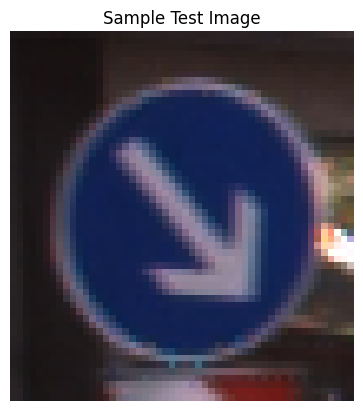

In [31]:
import matplotlib.pyplot as plt

img = cv2.imread(os.path.join(base_path, test_df.iloc[5]['Path']))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Sample Test Image")
plt.axis('off')

Conclusion:

the model achieved 99% validation accuracy and 94% test accuracy, demonstrating strong performance and good generalization.The overall model is reliable for real-world traffic sign detection applications.